# 01 · Inertia and the speed of a frequency fall
*Companion to* **Biggest Power Grid Failures: Engineering Analysis of History's Most Severe Blackouts, Cascades, and Grid Failures** *by Ganesh Kumar Pandey.* See **Chapter 2, Sections 2.3 and Figure 2.1**.

When a generator trips, the first thing that resists the frequency fall is not any controller. It is the
kinetic energy stored in every spinning synchronous machine. The system-level swing equation gives the
initial rate of change of frequency (RoCoF):

$$\frac{df}{dt}\Big|_{t=0^+} = -\frac{f_0\,\Delta P}{2\,E_k}$$

Halve the inertia and the frequency falls twice as fast, leaving half the time for reserves to respond.
This is the core reason high-renewable grids (UK 2019, Iberia 2025) need fast frequency response.

> **Model note.** This is a simplified teaching model. Parameters are chosen to be plausible and to reproduce the *shape* of the reported event, not to replicate any operator's measured data. For the authoritative record, read the official report cited in the book.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
from gridfail import plotstyle as ps
ps.apply()
FIG = os.path.abspath(os.path.join('..', 'figures'))

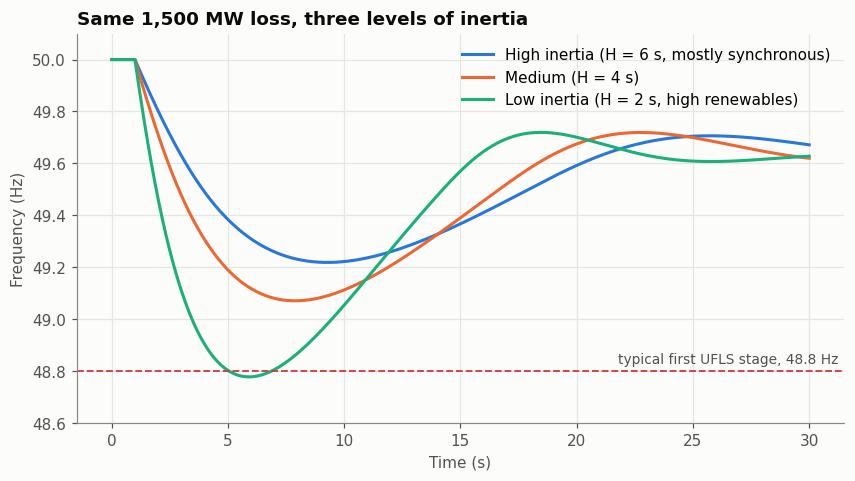

Case                                              RoCoF (Hz/s)  Nadir (Hz)  t to nadir (s)
High inertia (H = 6 s, mostly synchronous)              -0.208      49.219             8.3
Medium (H = 4 s)                                        -0.312      49.071             6.9
Low inertia (H = 2 s, high renewables)                  -0.625      48.778             4.9


In [2]:
from gridfail.frequency import FreqSystem, GenLoss, ShedStage, simulate, rocof_initial

DEMAND = 30000     # MW
LOSS = 1500        # MW, sudden generation loss at t = 1 s
H_cases = {'High inertia (H = 6 s, mostly synchronous)': 6.0,
           'Medium (H = 4 s)': 4.0,
           'Low inertia (H = 2 s, high renewables)': 2.0}

fig, ax = plt.subplots()
rows = []
for (label, H), c in zip(H_cases.items(), ps.SERIES):
    ek = H * DEMAND
    s = FreqSystem(demand_mw=DEMAND, ek_mws=ek, reserve_mw=1800, reserve_tc=8,
                   load_damping=0.02, losses=[GenLoss(1.0, LOSS, 0, 'unit trip')])
    r = simulate(s, t_end=30, dt=0.005)
    ax.plot(r['t'], r['f'], color=c, label=label)
    i = np.nanargmin(r['f'])
    rows.append((label, rocof_initial(LOSS, ek), r['f'][i], r['t'][i] - 1.0))

ps.threshold(ax, 48.8, 'typical first UFLS stage, 48.8 Hz')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Frequency (Hz)')
ax.set_title('Same 1,500 MW loss, three levels of inertia')
ax.set_ylim(48.6, 50.1); ax.legend(loc='upper right')
fig.savefig(os.path.join(FIG, '01_inertia_rocof.png'))
plt.show()

print(f"{'Case':48s} {'RoCoF (Hz/s)':>13s} {'Nadir (Hz)':>11s} {'t to nadir (s)':>15s}")
for lab, rocof, nadir, tn in rows:
    print(f"{lab:48s} {rocof:13.3f} {nadir:11.3f} {tn:15.1f}")

**Reading the result.** The reserve is identical in all three cases, yet the low-inertia system falls
fastest and deepest, because the same governor lag now has to fight a steeper slope. The low-inertia case
crosses the first load-shedding threshold; the others do not.

**Try it:** raise `reserve_tc` (slower reserve) or add `fast_reserve_mw=500, fast_reserve_tc=0.5`
(a battery) to the low-inertia case and see how much nadir you buy back.